In [1]:
# ============================================================
# PROJECT: WEAPON DETECTION IN SURVEILLANCE
# AUTHOR: Manideep
# PURPOSE:
# Detect Knife, Pistol, and No-Weapon Images
# Using CNN and Transfer Learning (MobileNetV2)
# ============================================================


# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# Basic libraries
import os
import json
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical computation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

# TensorFlow and Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# Transfer Learning Model
from tensorflow.keras.applications import MobileNetV2

# Display versions
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

# Check GPU
print("\nGPU Available:", tf.config.list_physical_devices('GPU'))

2026-06-06 21:05:08.235366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780779908.439702      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780779908.498106      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780779909.007428      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780779909.007471      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780779909.007474      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
NumPy Version: 2.4.6
Pandas Version: 2.3.3

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# DATASET LOADING AND AUTOMATIC DATASET CREATION
# ============================================================

import os
import json
import shutil
import random

# ============================================================
# CREATE FINAL DATASET FOLDER
# ============================================================

base_dir = "/kaggle/working/final_weapon_dataset"

train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

classes = ["knife", "pistol", "no_weapon"]

# Create folders
for split in [train_dir, valid_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

print("Folders created successfully!")


# ============================================================
# DATASET PATHS (FIXED)
# ============================================================

weapon_dataset_path = (
    "/kaggle/input/datasets/manideepgalipelli/"
    "weapon-detection-dataset/"
    "guns-knives-coco/guns-knives-coco"
)

human_dataset_path = (
    "/kaggle/input/datasets/manideepgalipelli/"
    "weapon-detection-dataset/"
    "human detection dataset/"
    "human detection dataset"
)


# ============================================================
# CHECK FILES INSIDE TRAIN FOLDER
# ============================================================

print("\nTrain Folder Files:")
print(os.listdir(os.path.join(weapon_dataset_path, "train"))[:10])


# ============================================================
# FIND ANNOTATION FILE AUTOMATICALLY
# ============================================================

train_folder = os.path.join(weapon_dataset_path, "train")

annotation_file = None

for file in os.listdir(train_folder):
    if file.endswith(".json"):
        annotation_file = os.path.join(train_folder, file)

print("\nAnnotation File Found:")
print(annotation_file)


# ============================================================
# LOAD COCO JSON FILE
# ============================================================

with open(annotation_file, "r") as f:
    coco_data = json.load(f)

print("\nCOCO annotation loaded successfully!")


# ============================================================
# CATEGORY MAPPING
# ============================================================

category_mapping = {
    1: "knife",
    2: "pistol"
}


# ============================================================
# IMAGE ID TO FILE NAME MAPPING
# ============================================================

image_id_to_name = {}

for image in coco_data["images"]:
    image_id_to_name[image["id"]] = image["file_name"]

print("Image mapping created!")


# ============================================================
# COPY WEAPON IMAGES
# ============================================================

copied_count = {
    "knife": 0,
    "pistol": 0
}

for annotation in coco_data["annotations"]:

    category_id = annotation["category_id"]

    if category_id in category_mapping:

        class_name = category_mapping[category_id]

        image_id = annotation["image_id"]

        file_name = image_id_to_name[image_id]

        source_path = os.path.join(
            train_folder,
            file_name
        )

        destination_path = os.path.join(
            train_dir,
            class_name,
            file_name
        )

        if os.path.exists(source_path):
            shutil.copy(source_path, destination_path)
            copied_count[class_name] += 1


print("\nWeapon Images Copied Successfully!")
print(copied_count)


# ============================================================
# ADD NO-WEAPON IMAGES
# ============================================================

human_images = []

for file in os.listdir(human_dataset_path):

    if file.endswith((".png", ".jpg", ".jpeg")):
        human_images.append(file)

random.shuffle(human_images)

train_no_weapon = human_images[:390]
valid_no_weapon = human_images[390:475]
test_no_weapon = human_images[475:]


# Copy train images
for image in train_no_weapon:

    src = os.path.join(human_dataset_path, image)

    dst = os.path.join(
        train_dir,
        "no_weapon",
        image
    )

    shutil.copy(src, dst)


# Copy validation images
for image in valid_no_weapon:

    src = os.path.join(human_dataset_path, image)

    dst = os.path.join(
        valid_dir,
        "no_weapon",
        image
    )

    shutil.copy(src, dst)


# Copy test images
for image in test_no_weapon:

    src = os.path.join(human_dataset_path, image)

    dst = os.path.join(
        test_dir,
        "no_weapon",
        image
    )

    shutil.copy(src, dst)

print("\nNo-weapon images added successfully!")


# ============================================================
# FINAL DATASET SUMMARY
# ============================================================

print("\nFINAL DATASET SUMMARY")

for split_name, split_path in zip(
    ["Train", "Validation", "Test"],
    [train_dir, valid_dir, test_dir]
):

    print(f"\n{split_name} Dataset")

    for cls in classes:

        class_path = os.path.join(
            split_path,
            cls
        )

        total_images = len(
            os.listdir(class_path)
        )

        print(f"{cls}: {total_images}")

Folders created successfully!

Train Folder Files:
['armas--1041-_jpg.rf.f26660bf41c43e6c24200c49c0943b9b.jpg', 'armas--267-_jpg.rf.5eb2aa682eda84f2177294080645cc4b.jpg', 'knife_1041_jpg.rf.c596e92aec7d58a479ef7b0ca06fc5b0.jpg', 'k552_jpg.rf.e8afe11f1b9b334d1eea985b947af5f9.jpg', 'knife_1015_jpg.rf.2068e693db4a720bcb99cf5b47ddf1a1.jpg', 'k87_jpg.rf.3fc5f22a91f5b023cb54d97bec29160b.jpg', 'knife_359_jpg.rf.c79a2619bcdb48a0fbf389803dd75631.jpg', 'armas--2188-_jpg.rf.1b67472134da6d268fac2f764e1979bb.jpg', 'KnifeDefenseKrav020_jpg.rf.e3fc5939996565e4061a38368faa0b4f.jpg', 'KnifeDefenseKrav060_jpg.rf.f595e6b1fe37d0247be3f87b64b6e8dd.jpg']

Annotation File Found:
/kaggle/input/datasets/manideepgalipelli/weapon-detection-dataset/guns-knives-coco/guns-knives-coco/train/_annotations.coco.json

COCO annotation loaded successfully!
Image mapping created!

Weapon Images Copied Successfully!
{'knife': 2766, 'pistol': 2344}

No-weapon images added successfully!

FINAL DATASET SUMMARY

Train Dataset
k

In [3]:
# ============================================================
# FIX DATASET SPLIT (TRAIN / VALID / TEST)
# ============================================================

from sklearn.model_selection import train_test_split
import glob

# Remove old dataset
shutil.rmtree(base_dir)

# Recreate folders
for split in [train_dir, valid_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

print("Old dataset removed and new folders created!")


# ============================================================
# SPLIT WEAPON IMAGES
# ============================================================

for class_name in ["knife", "pistol"]:

    image_paths = []

    for annotation in coco_data["annotations"]:

        category_id = annotation["category_id"]

        if category_mapping.get(category_id) == class_name:

            image_id = annotation["image_id"]

            file_name = image_id_to_name[image_id]

            image_path = os.path.join(
                train_folder,
                file_name
            )

            if os.path.exists(image_path):
                image_paths.append(image_path)

    # Remove duplicates
    image_paths = list(set(image_paths))

    # Split data
    train_imgs, temp_imgs = train_test_split(
        image_paths,
        test_size=0.30,
        random_state=42
    )

    valid_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    print(f"\n{class_name.upper()} Split")
    print("Train:", len(train_imgs))
    print("Validation:", len(valid_imgs))
    print("Test:", len(test_imgs))


    # Copy Train
    for img in train_imgs:
        shutil.copy(
            img,
            os.path.join(
                train_dir,
                class_name,
                os.path.basename(img)
            )
        )

    # Copy Validation
    for img in valid_imgs:
        shutil.copy(
            img,
            os.path.join(
                valid_dir,
                class_name,
                os.path.basename(img)
            )
        )

    # Copy Test
    for img in test_imgs:
        shutil.copy(
            img,
            os.path.join(
                test_dir,
                class_name,
                os.path.basename(img)
            )
        )


# ============================================================
# SPLIT NO-WEAPON IMAGES
# ============================================================

human_images = []

for file in os.listdir(human_dataset_path):
    if file.endswith((".png", ".jpg", ".jpeg")):
        human_images.append(
            os.path.join(human_dataset_path, file)
        )

random.shuffle(human_images)

train_human, temp_human = train_test_split(
    human_images,
    test_size=0.30,
    random_state=42
)

valid_human, test_human = train_test_split(
    temp_human,
    test_size=0.50,
    random_state=42
)

# Copy no_weapon images
for split_name, image_list in zip(
    [train_dir, valid_dir, test_dir],
    [train_human, valid_human, test_human]
):

    for img in image_list:

        shutil.copy(
            img,
            os.path.join(
                split_name,
                "no_weapon",
                os.path.basename(img)
            )
        )


# ============================================================
# FINAL DATASET CHECK
# ============================================================

print("\nFINAL DATASET DISTRIBUTION")

for split_name, split_path in zip(
    ["Train", "Validation", "Test"],
    [train_dir, valid_dir, test_dir]
):

    print(f"\n{split_name}")

    for cls in classes:

        count = len(
            os.listdir(
                os.path.join(split_path, cls)
            )
        )

        print(f"{cls}: {count}")

Old dataset removed and new folders created!

KNIFE Split
Train: 1639
Validation: 351
Test: 352

PISTOL Split
Train: 1432
Validation: 307
Test: 308

FINAL DATASET DISTRIBUTION

Train
knife: 1639
pistol: 1432
no_weapon: 391

Validation
knife: 351
pistol: 307
no_weapon: 84

Test
knife: 352
pistol: 308
no_weapon: 84


DATASET SUMMARY


,Train,Validation,Test
knife,1639,351,352
pistol,1432,307,308
no_weapon,391,84,84



Total Images in Dataset: 4948
Number of Classes: 3
Classes: ['knife', 'pistol', 'no_weapon']


<Figure size 1000x600 with 0 Axes>

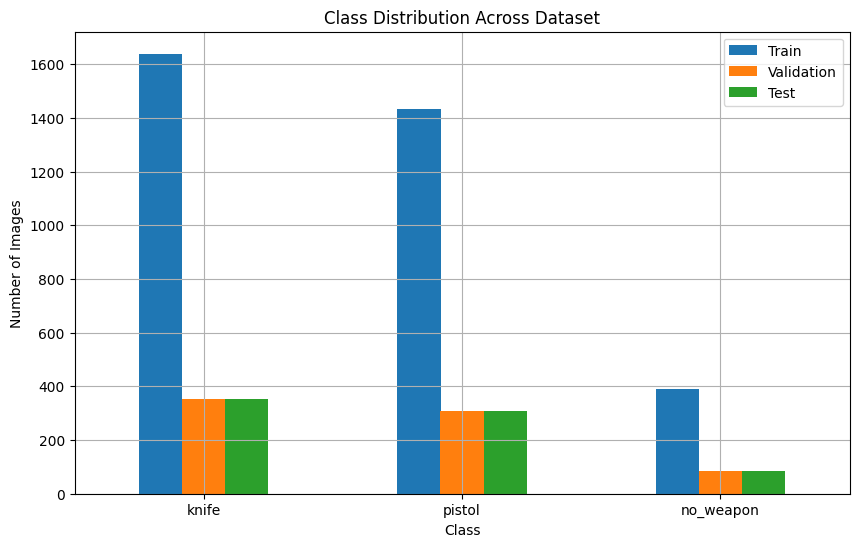

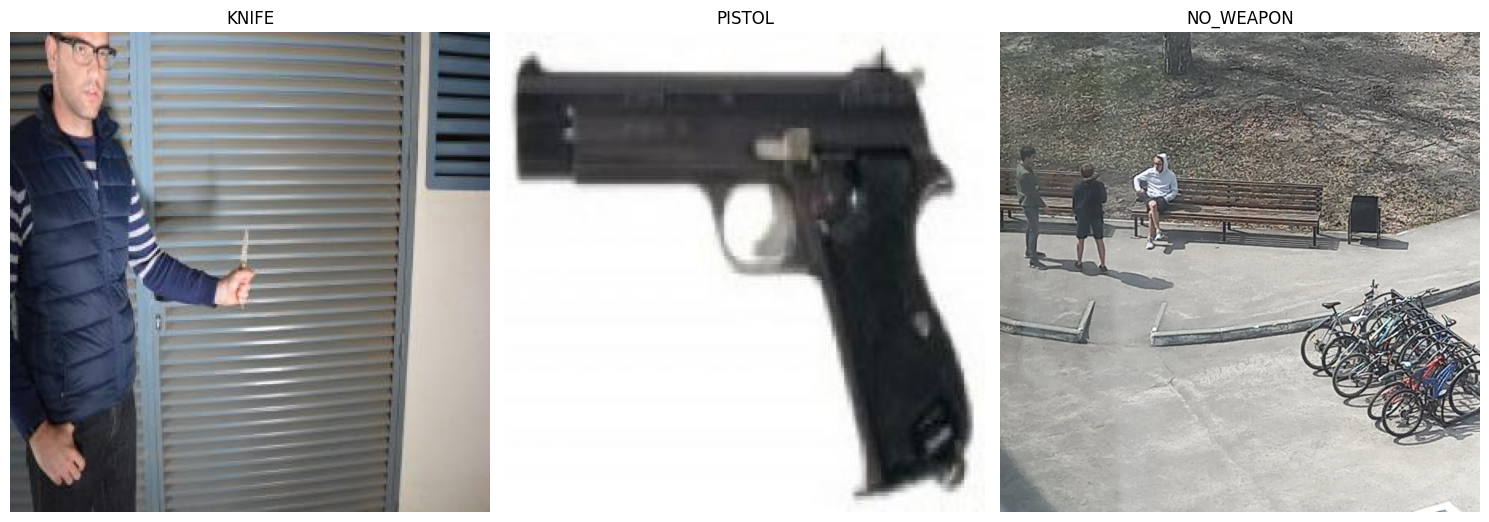

Figure Saved Successfully!
- class_distribution.png


<Figure size 640x480 with 0 Axes>


Figures saved successfully!
Saved Files:
- dataset_summary.csv
- class_distribution.png
- sample_images.png


In [4]:
# ============================================================
# DATASET EXPLORATION AND CLASS DISTRIBUTION
# ============================================================

# Create output folder for saving figures
output_dir = "/kaggle/working/output_figures"
os.makedirs(output_dir, exist_ok=True)

# Dataset summary dictionary
dataset_summary = {
    "Train": {},
    "Validation": {},
    "Test": {}
}

# Count images in each class
for split_name, split_path in zip(
    ["Train", "Validation", "Test"],
    [train_dir, valid_dir, test_dir]
):

    for cls in classes:

        class_path = os.path.join(split_path, cls)

        total_images = len(os.listdir(class_path))

        dataset_summary[split_name][cls] = total_images


# ============================================================
# DISPLAY DATASET SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame(dataset_summary)

print("DATASET SUMMARY")
display(summary_df)


# Save summary table
summary_df.to_csv(
    "/kaggle/working/output_figures/dataset_summary.csv"
)


# ============================================================
# TOTAL IMAGES
# ============================================================

total_images = summary_df.sum().sum()

print(f"\nTotal Images in Dataset: {total_images}")

print(f"Number of Classes: {len(classes)}")
print(f"Classes: {classes}")


# ============================================================
# VISUALIZE CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

summary_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Class Distribution Across Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(True)

# Save figure
plt.savefig(
    "/kaggle/working/output_figures/class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(train_dir, cls)

    sample_image = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        sample_image
    )

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls.upper())
    plt.axis("off")

plt.tight_layout()

# Save figure
plt.savefig(
    "/kaggle/working/output_figures/sample_images.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
# Save Figure
plt.savefig('/kaggle/working/class_distribution.png',
            dpi=300,
            bbox_inches='tight')

print("Figure Saved Successfully!")
print("- class_distribution.png")

plt.show()

print("\nFigures saved successfully!")
print("Saved Files:")
print("- dataset_summary.csv")
print("- class_distribution.png")
print("- sample_images.png")

Image Size: (224, 224)
Batch Size: 32
Found 3462 images belonging to 3 classes.
Found 742 images belonging to 3 classes.
Found 744 images belonging to 3 classes.

Class Mapping:
{'knife': 0, 'no_weapon': 1, 'pistol': 2}


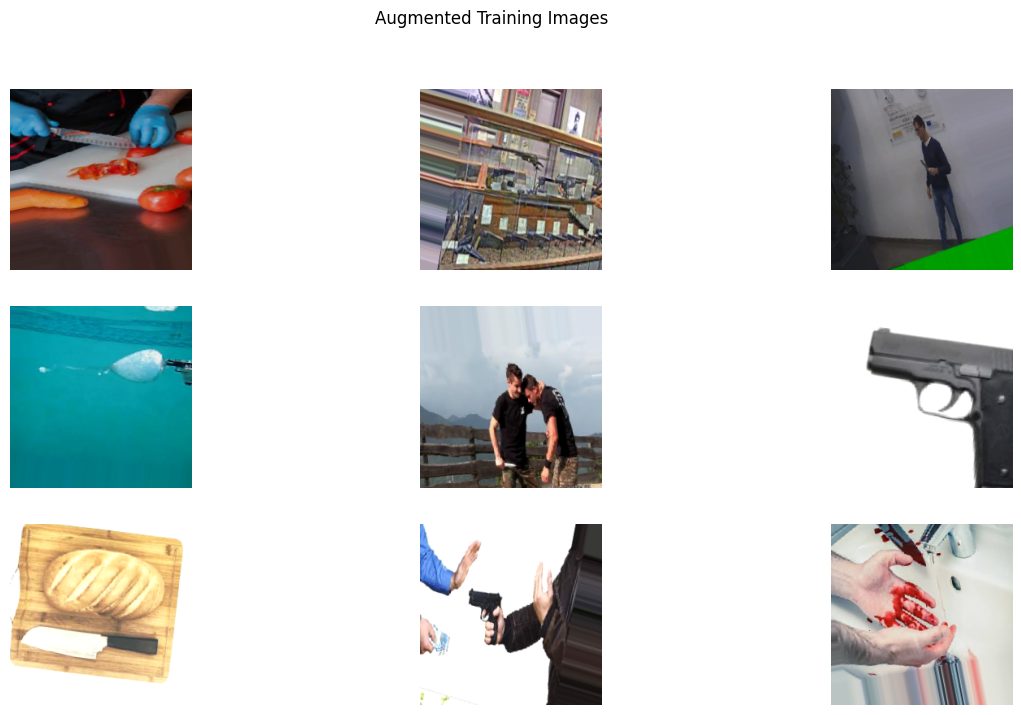


Augmented images figure saved successfully!


In [5]:
# ============================================================
# IMAGE PREPROCESSING AND DATA AUGMENTATION
# ============================================================

# Define image size and batch size
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image Size:", IMAGE_SIZE)
print("Batch Size:", BATCH_SIZE)


# ============================================================
# TRAIN DATA AUGMENTATION
# ============================================================

train_datagen = ImageDataGenerator(

    # Normalize pixel values
    rescale=1./255,

    # Data augmentation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],

    fill_mode='nearest'
)


# ============================================================
# VALIDATION AND TEST PREPROCESSING
# ============================================================

valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)


# ============================================================
# CREATE DATA GENERATORS
# ============================================================

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=True
)


valid_generator = valid_test_datagen.flow_from_directory(

    valid_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)


test_generator = valid_test_datagen.flow_from_directory(

    test_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)


# ============================================================
# DISPLAY CLASS MAPPING
# ============================================================

print("\nClass Mapping:")
print(train_generator.class_indices)


# ============================================================
# DISPLAY AUGMENTED SAMPLE IMAGES
# ============================================================

sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(15,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(sample_images[i])

    plt.axis("off")

plt.suptitle("Augmented Training Images")

# Save figure
plt.savefig(
    "/kaggle/working/output_figures/augmented_images.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nAugmented images figure saved successfully!")

In [6]:
# ============================================================
# CUSTOM CNN MODEL DEVELOPMENT
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

# ============================================================
# BUILD CUSTOM CNN MODEL
# ============================================================

cnn_model = Sequential([

    # Input Layer + First Convolution Block
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Second Convolution Block
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Third Convolution Block
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Fourth Convolution Block
    Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    # Global Pooling Layer
    GlobalAveragePooling2D(),


    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),


    # Hidden Dense Layer
    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),


    # Output Layer
    Dense(
        3,
        activation='softmax'
    )
])


# ============================================================
# COMPILE CNN MODEL
# ============================================================

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


# ============================================================
# DISPLAY MODEL SUMMARY
# ============================================================

print("CUSTOM CNN MODEL SUMMARY\n")

cnn_model.summary()

I0000 00:00:1780780129.156821      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780780129.162863      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CUSTOM CNN MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,683 (1.65 MB)

 Trainable params: 430,723 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# ============================================================
# CNN MODEL TRAINING
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ============================================================
# CALLBACKS
# ============================================================

# Stop training if validation accuracy stops improving
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1
)


# Reduce learning rate automatically
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=0.000001,

    verbose=1
)


# Save best model
model_checkpoint = ModelCheckpoint(

    "/kaggle/working/best_cnn_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)


# ============================================================
# TRAIN CNN MODEL
# ============================================================

EPOCHS = 20

history_cnn = cnn_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

print("\nCNN Training Completed Successfully!")

Epoch 1/20


I0000 00:00:1780780144.703919     162 service.cc:152] XLA service 0x7bdc80009f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780780144.703974     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780780144.703979     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780780145.435379     162 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 21:09:08.685377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:09:08.833838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/109 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.3984 - loss: 1.3376  

I0000 00:00:1780780153.315940     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 83/109 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.4927 - loss: 1.1092

2026-06-06 21:09:47.281466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:09:47.423555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.4995 - loss: 1.0829
Epoch 1: val_accuracy improved from None to 0.39488, saving model to /kaggle/working/best_cnn_model.keras

Epoch 1: finished saving model to /kaggle/working/best_cnn_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 64s 477ms/step - accuracy: 0.5243 - loss: 0.9870 - val_accuracy: 0.3949 - val_loss: 0.9776 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.5624 - loss: 0.8796
Epoch 2: val_accuracy did not improve from 0.39488
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 409ms/step - accuracy: 0.5722 - loss: 0.8699 - val_accuracy: 0.3881 - val_loss: 1.0230 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6310 - loss: 0.8031
Epoch 3: val_accuracy improved from 0.39488 to 0.45957, saving model to /kaggle/working/best_cnn_model.keras

Epoch 3: finished saving model to /kaggle/working/best_cnn_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 410ms/step - acc

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7997 - loss: 0.4622

CNN TEST PERFORMANCE
Test Accuracy: 0.7997
Test Loss: 0.4622
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step

CLASSIFICATION REPORT


,precision,recall,f1-score,support
knife,0.815718,0.855114,0.834951,352.000000
no_weapon,0.601770,0.809524,0.690355,84.000000
pistol,0.862595,0.733766,0.792982,308.000000
accuracy,0.799731,0.799731,0.799731,0.799731
macro avg,0.760028,0.799468,0.772763,744.000000
weighted avg,0.810969,0.799731,0.801252,744.000000


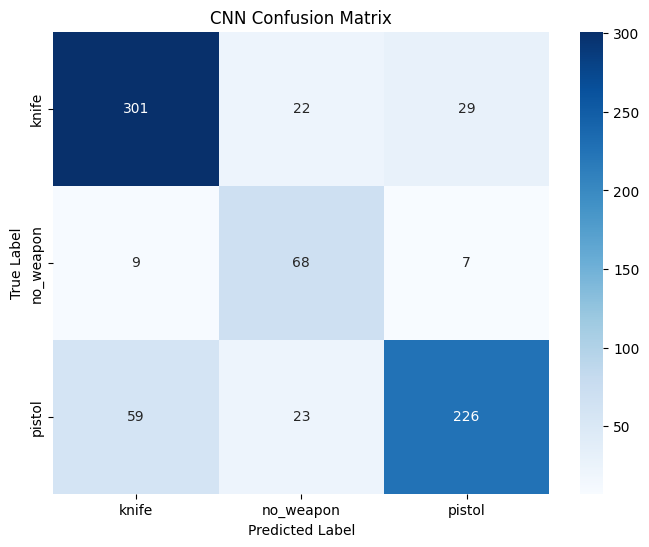


Files Saved Successfully!
- cnn_classification_report.csv
- cnn_confusion_matrix.png


In [8]:
# ============================================================
# CNN MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# EVALUATE MODEL ON TEST DATA
# ============================================================

test_loss, test_accuracy = cnn_model.evaluate(
    test_generator
)

print("\nCNN TEST PERFORMANCE")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


# ============================================================
# MAKE PREDICTIONS
# ============================================================

predictions = cnn_model.predict(
    test_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_labels = list(
    test_generator.class_indices.keys()
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    true_classes,

    predicted_classes,

    target_names=class_labels,

    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\nCLASSIFICATION REPORT")
display(report_df)


# Save classification report
report_df.to_csv(
    "/kaggle/working/output_figures/cnn_classification_report.csv"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save figure
plt.savefig(
    "/kaggle/working/output_figures/cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print("\nFiles Saved Successfully!")
print("- cnn_classification_report.csv")
print("- cnn_confusion_matrix.png")

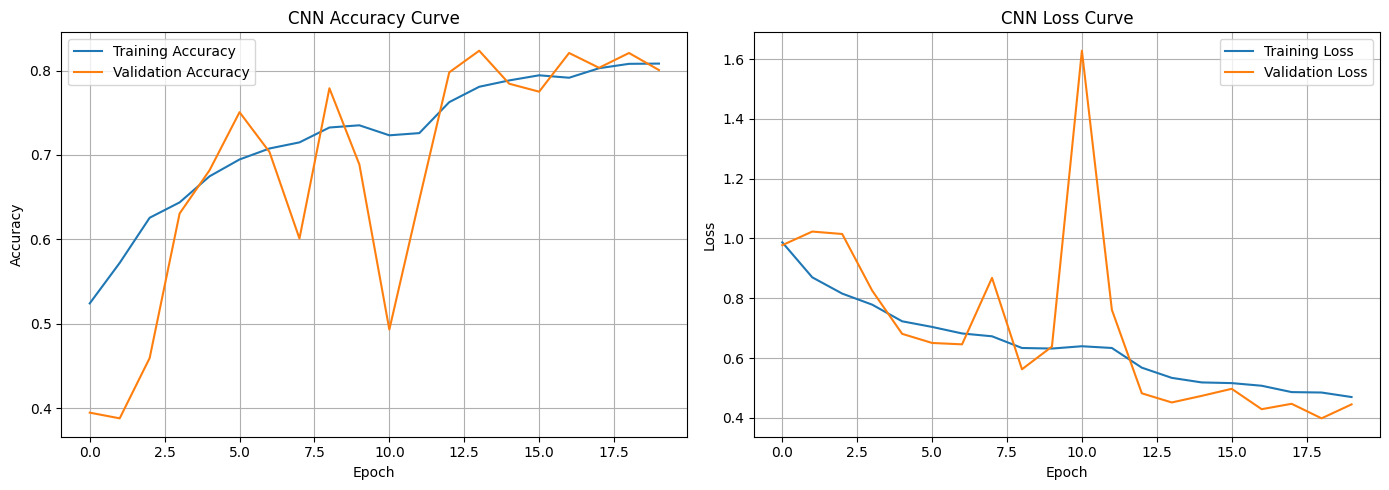

Figure Saved Successfully!
- cnn_accuracy_loss_curve.png


In [9]:
# ============================================================
# CNN ACCURACY AND LOSS CURVES
# ============================================================

# Create figure
plt.figure(figsize=(14,5))


# ============================================================
# ACCURACY CURVE
# ============================================================

plt.subplot(1,2,1)

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)


# ============================================================
# LOSS CURVE
# ============================================================

plt.subplot(1,2,2)

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "/kaggle/working/output_figures/cnn_accuracy_loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print("Figure Saved Successfully!")
print("- cnn_accuracy_loss_curve.png")

In [10]:
# ============================================================
# MOBILENETV2 TRANSFER LEARNING MODEL
# ============================================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam


# ============================================================
# LOAD PRETRAINED MOBILENETV2
# ============================================================

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)


# Freeze pretrained layers
base_model.trainable = False


# ============================================================
# CUSTOM CLASSIFICATION HEAD
# ============================================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    3,
    activation='softmax'
)(x)


# ============================================================
# FINAL MODEL
# ============================================================

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=outputs
)


# ============================================================
# COMPILE MODEL
# ============================================================

mobilenet_model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("MOBILENETV2 MODEL SUMMARY\n")

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MOBILENETV2 MODEL SUMMARY



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,430,403 (9.27 MB)

 Trainable params: 172,419 (673.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# ============================================================
# MOBILENETV2 TRAINING
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ============================================================
# CALLBACKS
# ============================================================

early_stopping_mobile = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1
)


reduce_lr_mobile = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=0.000001,

    verbose=1
)


model_checkpoint_mobile = ModelCheckpoint(

    "/kaggle/working/best_mobilenet_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)


# ============================================================
# TRAIN MOBILENETV2 MODEL
# ============================================================

EPOCHS = 15

history_mobile = mobilenet_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=EPOCHS,

    callbacks=[

        early_stopping_mobile,

        reduce_lr_mobile,

        model_checkpoint_mobile
    ]
)


print("\nMobileNetV2 Training Completed Successfully!")

Epoch 1/15


2026-06-06 21:26:21.466069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:26:21.607814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 95/109 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.4908 - loss: 1.1161

2026-06-06 21:27:09.182599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:27:09.319031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.5038 - loss: 1.0935
Epoch 1: val_accuracy improved from None to 0.80323, saving model to /kaggle/working/best_mobilenet_model.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenet_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 80s 577ms/step - accuracy: 0.5936 - loss: 0.9349 - val_accuracy: 0.8032 - val_loss: 0.5666 - learning_rate: 1.0000e-04
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.7276 - loss: 0.6667
Epoch 2: val_accuracy improved from 0.80323 to 0.82884, saving model to /kaggle/working/best_mobilenet_model.keras

Epoch 2: finished saving model to /kaggle/working/best_mobilenet_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 409ms/step - accuracy: 0.7395 - loss: 0.6383 - val_accuracy: 0.8288 - val_loss: 0.4178 - learning_rate: 1.0000e-04
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7846 - loss: 0.5467
Epoch 3: val_accuracy improved from 0.82884 to 0.87466, saving model

22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9584 - loss: 0.1335

2026-06-06 21:42:32.761291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:42:32.916042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 21:42:33.052447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 511ms/step - accuracy: 0.9409 - loss: 0.1681

MOBILENETV2 TEST PERFORMANCE
Test Accuracy: 0.9409
Test Loss: 0.1681
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step

MOBILENETV2 CLASSIFICATION REPORT


,precision,recall,f1-score,support
knife,0.944290,0.963068,0.953586,352.00000
no_weapon,0.932432,0.821429,0.873418,84.00000
pistol,0.938907,0.948052,0.943457,308.00000
accuracy,0.940860,0.940860,0.940860,0.94086
macro avg,0.938543,0.910850,0.923487,744.00000
weighted avg,0.940723,0.940860,0.940342,744.00000


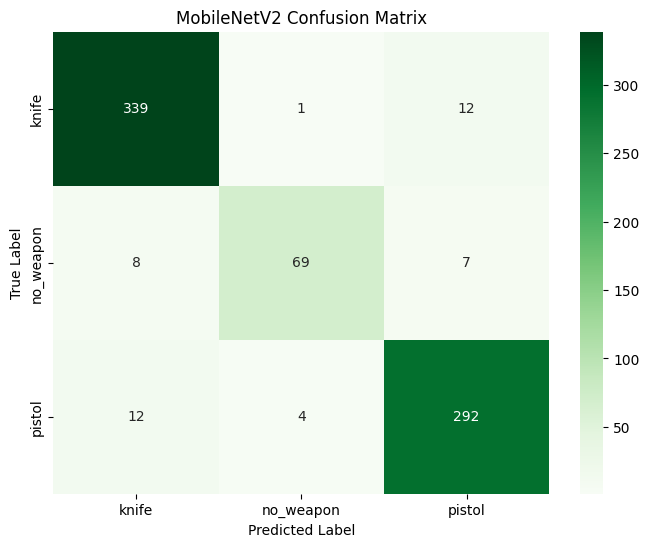


Files Saved Successfully!
- mobilenet_classification_report.csv
- mobilenet_confusion_matrix.png


In [12]:
# ============================================================
# MOBILENETV2 MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# ============================================================
# TEST PERFORMANCE
# ============================================================

test_loss_mobile, test_accuracy_mobile = mobilenet_model.evaluate(
    test_generator
)

print("\nMOBILENETV2 TEST PERFORMANCE")
print(f"Test Accuracy: {test_accuracy_mobile:.4f}")
print(f"Test Loss: {test_loss_mobile:.4f}")


# ============================================================
# MAKE PREDICTIONS
# ============================================================

mobile_predictions = mobilenet_model.predict(
    test_generator
)

mobile_predicted_classes = np.argmax(
    mobile_predictions,
    axis=1
)

true_classes = test_generator.classes

class_labels = list(
    test_generator.class_indices.keys()
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

mobile_report = classification_report(

    true_classes,

    mobile_predicted_classes,

    target_names=class_labels,

    output_dict=True
)

mobile_report_df = pd.DataFrame(
    mobile_report
).transpose()

print("\nMOBILENETV2 CLASSIFICATION REPORT")

display(mobile_report_df)


# Save report
mobile_report_df.to_csv(
    "/kaggle/working/output_figures/mobilenet_classification_report.csv"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_mobile = confusion_matrix(
    true_classes,
    mobile_predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_mobile,

    annot=True,

    fmt='d',

    cmap='Greens',

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.title("MobileNetV2 Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")


# Save figure
plt.savefig(

    "/kaggle/working/output_figures/mobilenet_confusion_matrix.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("\nFiles Saved Successfully!")
print("- mobilenet_classification_report.csv")
print("- mobilenet_confusion_matrix.png")

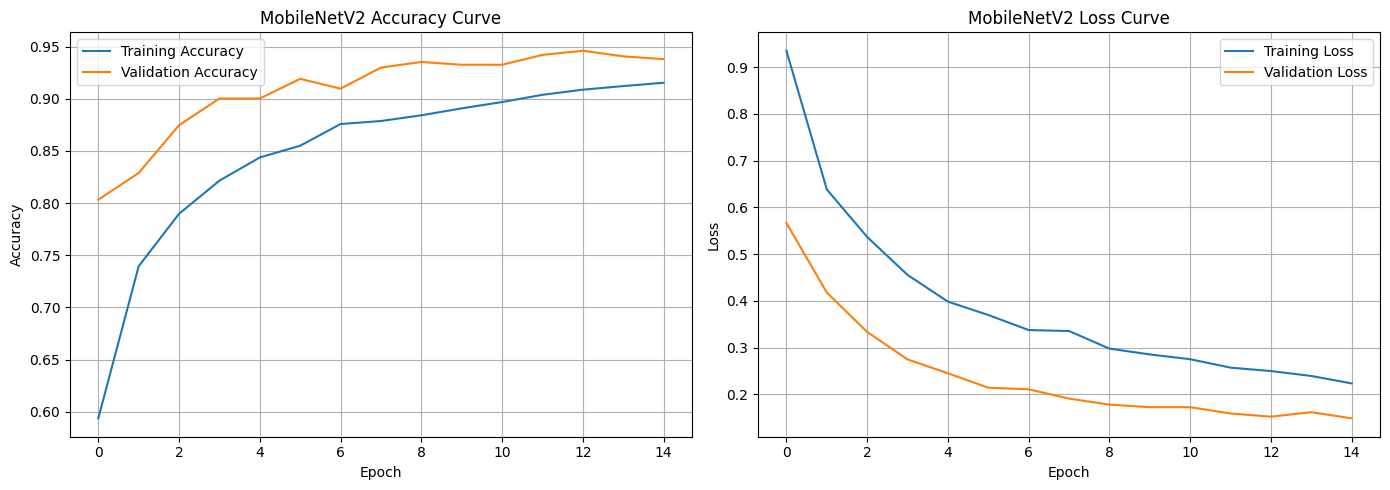

Figure Saved Successfully!
- mobilenet_accuracy_loss_curve.png


In [13]:
# ============================================================
# MOBILENETV2 ACCURACY AND LOSS CURVES
# ============================================================

plt.figure(figsize=(14,5))


# ============================================================
# ACCURACY CURVE
# ============================================================

plt.subplot(1,2,1)

plt.plot(
    history_mobile.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobile.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)


# ============================================================
# LOSS CURVE
# ============================================================

plt.subplot(1,2,2)

plt.plot(
    history_mobile.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobile.history['val_loss'],
    label='Validation Loss'
)

plt.title("MobileNetV2 Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "/kaggle/working/output_figures/mobilenet_accuracy_loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print("Figure Saved Successfully!")
print("- mobilenet_accuracy_loss_curve.png")

In [17]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

comparison_data = {

    "Model": [
        "Custom CNN",
        "MobileNetV2"
    ],

    "Test Accuracy": [
        test_accuracy,
        test_accuracy_mobile
    ],

    "Test Loss": [
        test_loss,
        test_loss_mobile
    ]
}


# ============================================================
# CREATE DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(
    comparison_data
)

# Convert to percentage
comparison_df["Test Accuracy"] = (
    comparison_df["Test Accuracy"] * 100
).round(2)

comparison_df["Test Loss"] = (
    comparison_df["Test Loss"]
).round(4)


# ============================================================
# DISPLAY TABLE
# ============================================================

print("MODEL COMPARISON TABLE")

display(comparison_df)


# ============================================================
# SAVE TABLE
# ============================================================

comparison_df.to_csv(

    "/kaggle/working/output_figures/model_comparison_table.csv",

    index=False
)

print("\nTable Saved Successfully!")
print("- model_comparison_table.csv")

MODEL COMPARISON TABLE


,Model,Test Accuracy,Test Loss
0,Custom CNN,79.97,0.4622
1,MobileNetV2,94.09,0.1681



Table Saved Successfully!
- model_comparison_table.csv


In [18]:
# ============================================================
# SAVE FINAL BEST MODEL
# ============================================================

mobilenet_model.save(

    "/kaggle/working/final_weapon_detection_model.keras"
)

print("Final Model Saved Successfully!")

print(
    "/kaggle/working/final_weapon_detection_model.keras"
)

Final Model Saved Successfully!
/kaggle/working/final_weapon_detection_model.keras


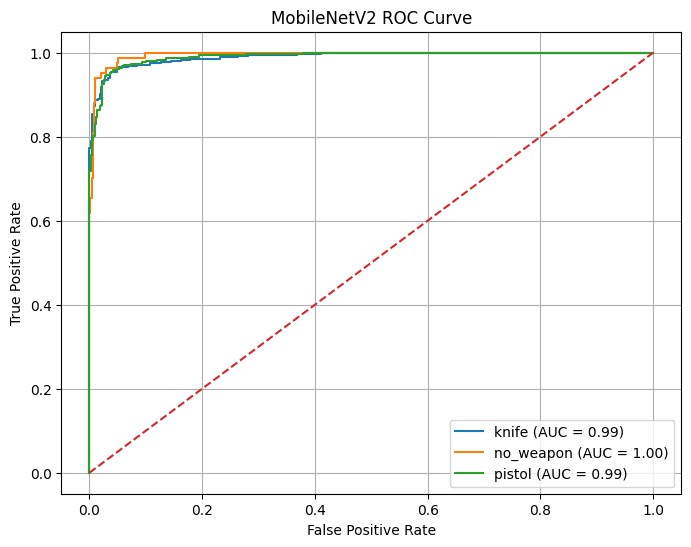

ROC Curve Saved Successfully!
- mobilenet_roc_curve.png


In [19]:
# ============================================================
# ROC CURVE FOR MULTI-CLASS CLASSIFICATION
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ============================================================
# BINARIZE LABELS
# ============================================================

true_classes_bin = label_binarize(
    true_classes,
    classes=[0,1,2]
)

num_classes = 3


# ============================================================
# PLOT ROC CURVE
# ============================================================

plt.figure(figsize=(8,6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        true_classes_bin[:, i],
        mobile_predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_labels[i]} (AUC = {roc_auc:.2f})'
    )

# Random line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MobileNetV2 ROC Curve")

plt.legend()

plt.grid(True)


# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "/kaggle/working/output_figures/mobilenet_roc_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("ROC Curve Saved Successfully!")
print("- mobilenet_roc_curve.png")

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
Total Misclassified Images: 44


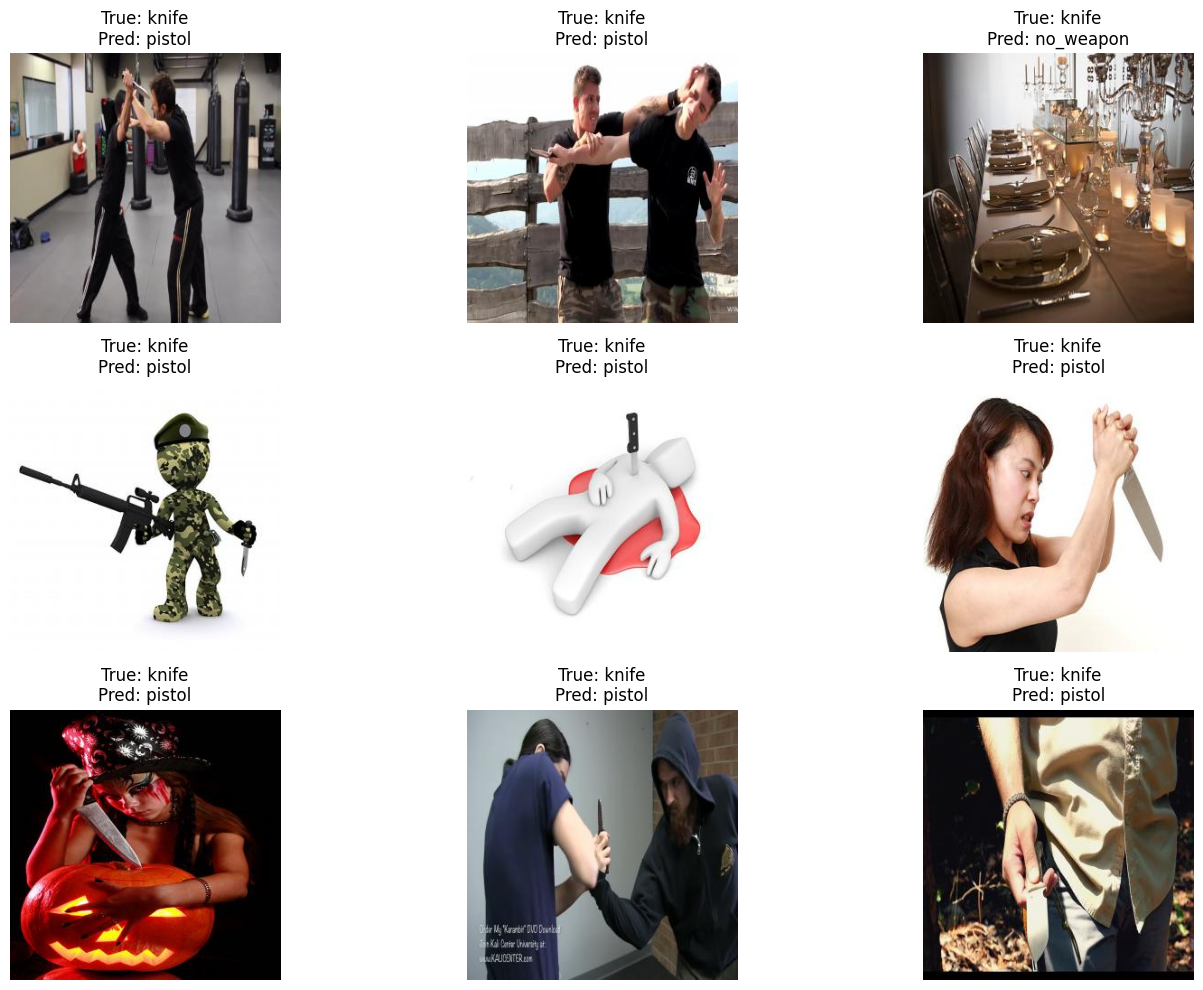

Figure Saved Successfully!
- error_analysis.png


In [20]:
# ============================================================
# ERROR ANALYSIS - MISCLASSIFIED IMAGES
# ============================================================

# Reset generator
test_generator.reset()

# Predictions
predictions = mobilenet_model.predict(
    test_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_labels = list(
    test_generator.class_indices.keys()
)

# ============================================================
# FIND WRONG PREDICTIONS
# ============================================================

misclassified = np.where(
    predicted_classes != true_classes
)[0]

print(
    f"Total Misclassified Images: {len(misclassified)}"
)

# ============================================================
# DISPLAY MISCLASSIFIED IMAGES
# ============================================================

num_images = min(9, len(misclassified))

plt.figure(figsize=(15,10))

for i in range(num_images):

    idx = misclassified[i]

    img_path = test_generator.filepaths[idx]

    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    true_label = class_labels[
        true_classes[idx]
    ]

    pred_label = class_labels[
        predicted_classes[idx]
    ]

    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(

    "/kaggle/working/output_figures/error_analysis.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("Figure Saved Successfully!")
print("- error_analysis.png")